# Representation Learning and Auto Encoder

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# MNIST Dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

## Loading, Pre-processing and adding Noise to dataset

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


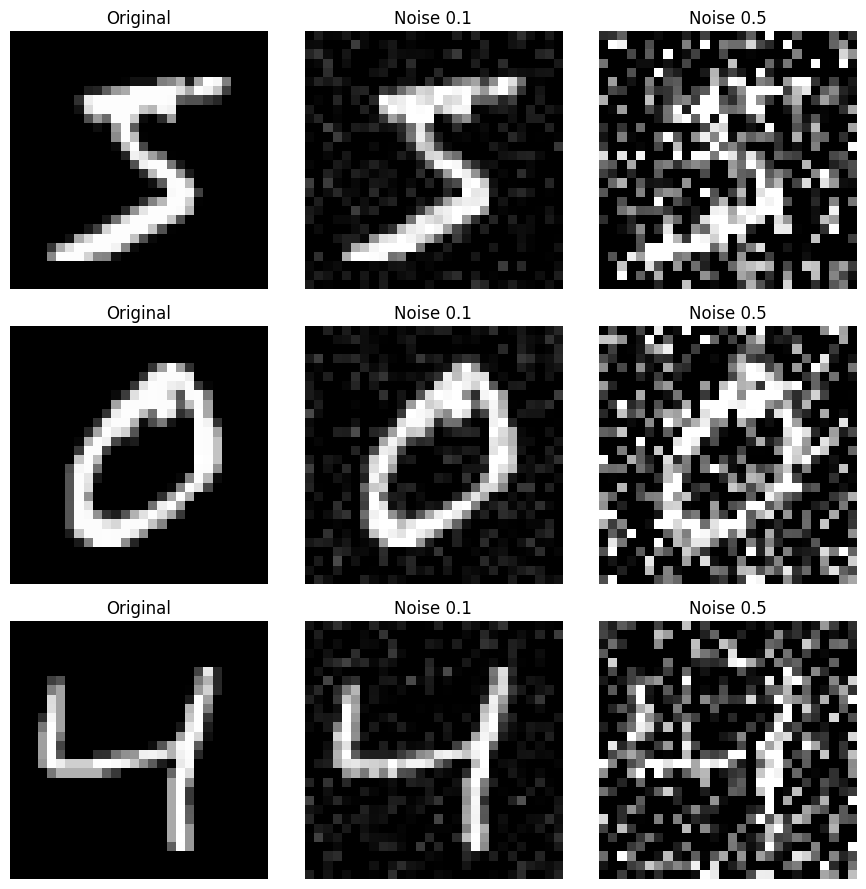

In [ ]:
# Load and preprocess MNIST
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))
#Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5
x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.
shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train
.shape)
x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)
#Visualize in a 3 x 3 grid
n = 3 # number of images to show
plt.figure(figsize=(9, 9))
for i in range(n):
  # Original image
  ax = plt.subplot(n, 3, i * 3 + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
  plt.title("Original")
  plt.axis('off')
  # Low noise image
  ax = plt.subplot(n, 3, i * 3 + 2)
  plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
  plt.title("Noise 0.1")
  plt.axis('off')
  # High noise image
  ax = plt.subplot(n, 3, i * 3 + 3)
  plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
  plt.title("Noise 0.5")
  plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from keras.models import Model
from keras.optimizers import Adam

## Encoder

In [ ]:
def build_encoder(input_shape=(28, 28, 1)):
  """
  Builds the encoder part of the convolutional autoencoder.
  Parameters:
  input_shape (tuple): Shape of the input image. Default is (28, 28, 1) for MNIST.
  Returns:
  input_img (Keras Input): Input layer of the model.
  encoded (Keras Tensor): Encoded representation after convolution and pooling.
  """
  input_img = Input(shape=input_shape, name="input")
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
  x = MaxPooling2D((2, 2), padding='same')(x)
  x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
  encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
  return input_img, encoded

## Decoder

In [ ]:
def build_decoder(encoded_input):
  """
  Builds the decoder part of the convolutional autoencoder.
  Parameters:
  encoded_input (Keras Tensor): The output from the encoder.
  Returns:
  decoded (Keras Tensor): The reconstructed output after upsampling and
  convolution.
  """
  x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
  x = UpSampling2D((2, 2))(x)
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
  x = UpSampling2D((2, 2))(x)
  decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
  return decoded

## AutoEncoder

In [ ]:
def build_autoencoder():
  """
  Constructs and compiles the full convolutional autoencoder by connecting encoder and
  decoder.
  Returns:
  autoencoder (Keras Model): Compiled autoencoder model.
  """
  input_img, encoded_output = build_encoder()
  decoded_output = build_decoder(encoded_output)
  autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
  autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
  return autoencoder

## Compiling the model

In [ ]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## Training the Auto Encoder

In [ ]:
# Train with noisy input and clean target
history = autoencoder.fit(
  x_train_noisy_high, x_train,
  epochs=10,
  batch_size=128,
  shuffle=True,
  validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 199s 419ms/step - loss: 0.1561 - val_loss: 0.1132
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 191s 407ms/step - loss: 0.1100 - val_loss: 0.1054
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 192s 409ms/step - loss: 0.1047 - val_loss: 0.1018
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 402ms/step - loss: 0.1017 - val_loss: 0.1000
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 191s 407ms/step - loss: 0.1000 - val_loss: 0.0984
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 193s 411ms/step - loss: 0.0988 - val_loss: 0.0976
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 191s 407ms/step - loss: 0.0979 - val_loss: 0.0967
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 187s 399ms/step - loss: 0.0972 - val_loss: 0.0963
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 190s 405ms/step - loss: 0.0966 - val_loss: 0.0957
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 188s 400ms/step - loss: 0.0960 - val_loss: 0.0954


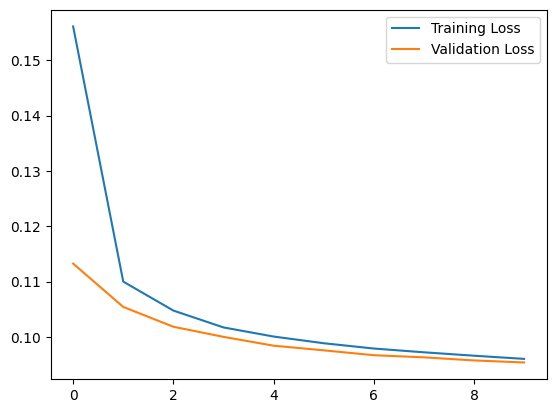

In [ ]:
# Training vs Validation
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

## Evaluating the AutoEncoder

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step


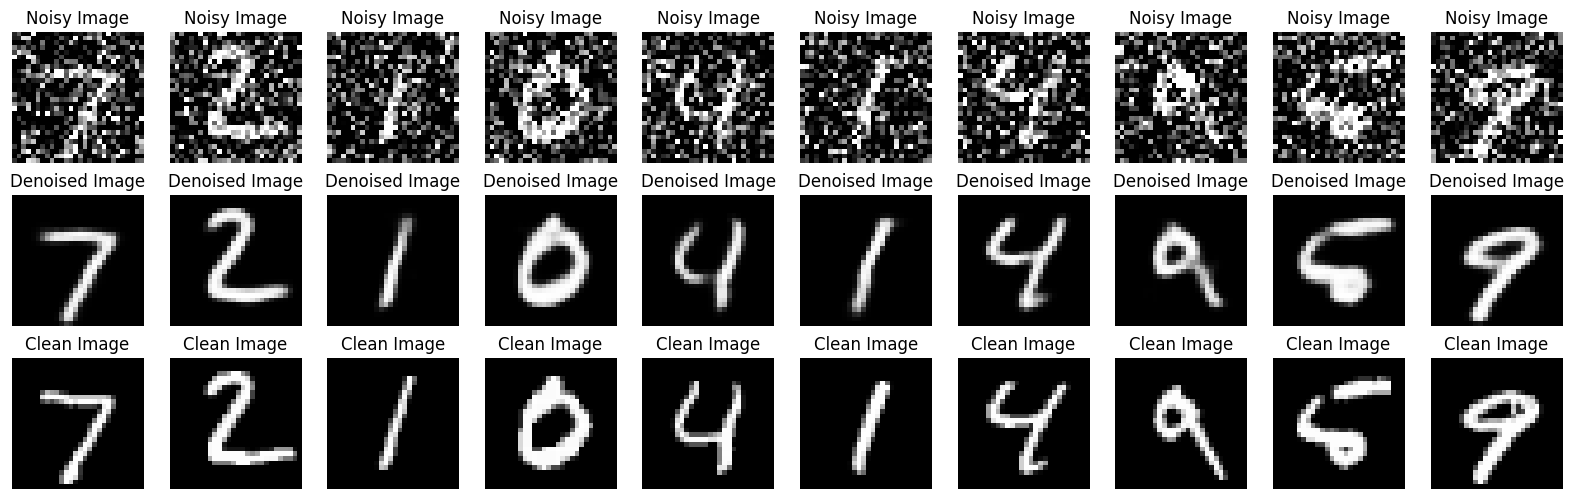

In [ ]:
# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)
# Function to display images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
  plt.figure(figsize=(20, 6))
  for i in range(n):
    # Plot noisy images
    plt.subplot(3, n, i + 1)
    plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy Image")
    plt.axis('off')
    # Plot denoised images
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised Image")
    plt.axis('off')
    # Plot clean images
    plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
    plt.title("Clean Image")
    plt.axis('off')
  plt.show()
# Display the first 10 images
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

# Devnagari Handwritten Dataset

In [ ]:
from PIL import Image
import os

In [ ]:
train_dir = "/content/drive/MyDrive/AI and Machine Learning /Workshop4/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI and Machine Learning /Workshop4/DevanagariHandwrittenDigitDataset/Test"
img_height, img_width = 28,28

In [ ]:
def load_images(data_dir):
    images=[]
    for class_name in os.listdir(data_dir):
        class_path=os.path.join(data_dir,class_name)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                img_path=os.path.join(
                    class_path,
                    img_name
                )
                img=Image.open(img_path).convert('L')
                img=img.resize((28,28))
                img=np.array(img)/255.0
                images.append(img)
    return np.array(images)

In [ ]:
x_train=load_images(train_dir)
x_test=load_images(test_dir)

In [ ]:
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)

print(x_train.shape)
print(x_test.shape)

(17000, 28, 28, 1)
(3000, 28, 28, 1)


In [ ]:
noise_factor=0.5

x_train_noisy = x_train + noise_factor*np.random.normal(
    loc=0,
    scale=1,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor*np.random.normal(
    loc=0,
    scale=1,
    size=x_test.shape
)

x_train_noisy=np.clip(x_train_noisy,0.,1.)
x_test_noisy=np.clip(x_test_noisy,0.,1.)

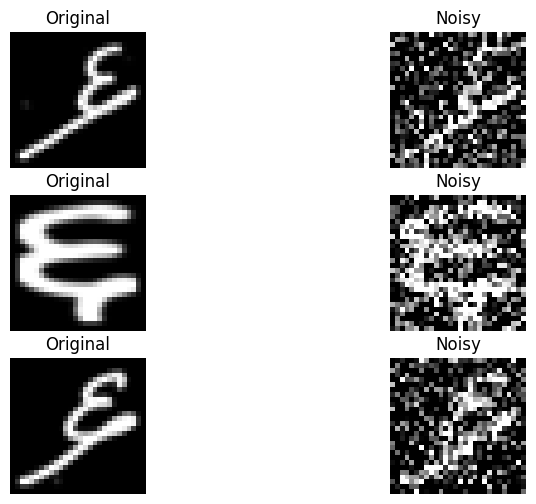

In [ ]:
plt.figure(figsize=(9,6))

for i in range(3):

    plt.subplot(3,2,2*i+1)
    plt.imshow(
        x_train[i].reshape(28,28),
        cmap='gray'
    )
    plt.title("Original")
    plt.axis('off')


    plt.subplot(3,2,2*i+2)
    plt.imshow(
        x_train_noisy[i].reshape(28,28),
        cmap='gray'
    )
    plt.title("Noisy")
    plt.axis('off')

plt.show()

In [ ]:
input_img=Input(shape=(28,28,1))

# Encoder
x=Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(input_img)

x=MaxPooling2D((2,2),padding='same')(x)

x=Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x=MaxPooling2D((2,2),padding='same')(x)

encoded=Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(x)



# Decoder
x=Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(encoded)

x=UpSampling2D((2,2))(x)

x=Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x=UpSampling2D((2,2))(x)

x=Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(x)

decoded=Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

In [ ]:
autoencoder=Model(input_img,decoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(
        x_test_noisy,
        x_test
    )
)

Epoch 1/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - loss: 0.3032 - val_loss: 0.2054
Epoch 2/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - loss: 0.1967 - val_loss: 0.1917
Epoch 3/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - loss: 0.1876 - val_loss: 0.1867
Epoch 4/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - loss: 0.1838 - val_loss: 0.1822
Epoch 5/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - loss: 0.1812 - val_loss: 0.1799
Epoch 6/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - loss: 0.1792 - val_loss: 0.1787
Epoch 7/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - loss: 0.1780 - val_loss: 0.1782
Epoch 8/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - loss: 0.1766 - val_loss: 0.1764
Epoch 9/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - loss: 0.1757 - val_loss: 0.1758
Epoch 10/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - loss: 0.1748 - val_loss: 0.1754
Epoch 11/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - loss: 0.1739 - val_loss: 0.1750
Epoch 12/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
denoised=autoencoder.predict(x_test_noisy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step


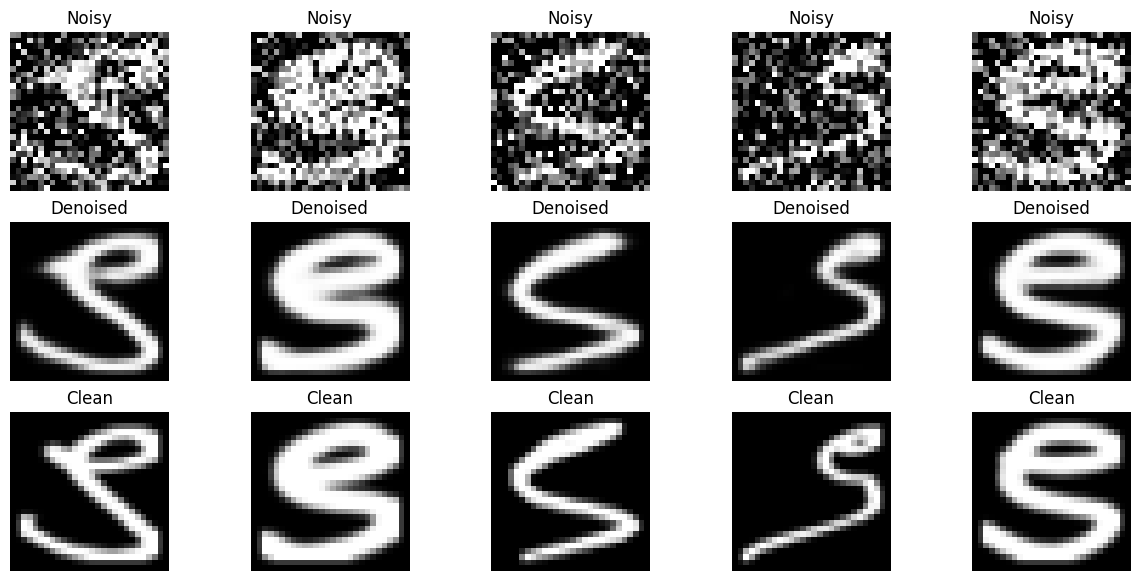

In [ ]:
n=5

plt.figure(figsize=(15,7))

for i in range(n):

    plt.subplot(3,n,i+1)
    plt.imshow(
      x_test_noisy[i].reshape(28,28),
      cmap='gray'
    )
    plt.title("Noisy")
    plt.axis('off')


    plt.subplot(3,n,n+i+1)
    plt.imshow(
      denoised[i].reshape(28,28),
      cmap='gray'
    )
    plt.title("Denoised")
    plt.axis('off')


    plt.subplot(3,n,2*n+i+1)
    plt.imshow(
      x_test[i].reshape(28,28),
      cmap='gray'
    )
    plt.title("Clean")
    plt.axis('off')

plt.show()